In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# read results
results = pd.read_csv("results/sim_classification.csv")
results.head()

,iteration,method,metric,value
0,0,EnrichMap,AUROC,0.992789
1,0,EnrichMap,AUPRC,0.986474
2,0,EnrichMap,F1,0.964611
3,0,EnrichMap,KS,0.953127
4,0,EnrichMap,Spatial coherence,0.996393


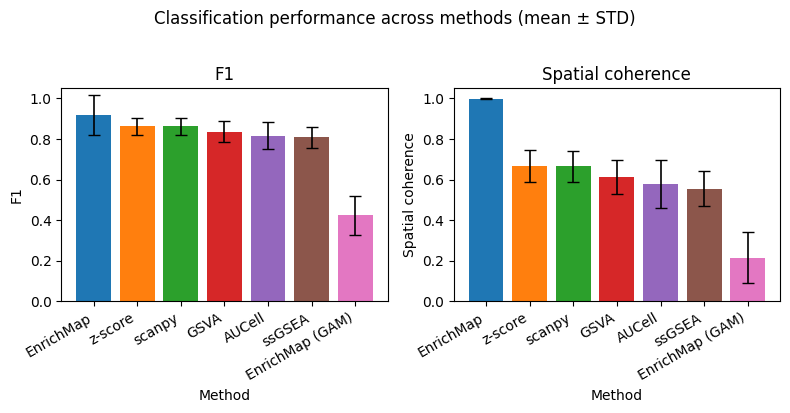

In [11]:
# Plot F1 and Spatial coherence as separate panels
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, metric in zip(axes, ["F1", "Spatial coherence"]):
    sub = results[results["metric"] == metric]
    agg = sub.groupby("method")["value"].agg(["mean", "std"]).reset_index()
    agg = agg.sort_values("mean", ascending=False)

    ax.bar(
        agg["method"], agg["mean"],
        yerr=agg["std"], capsize=4,
        color=sns.color_palette("tab10", len(agg)),
        error_kw=dict(elinewidth=1.2, ecolor="black"),
    )
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Method")
    ax.tick_params(axis="x", rotation=30)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")

plt.suptitle("Classification performance across methods (mean ± STD)", y=1.02)
plt.tight_layout()
plt.savefig("figures/simulation_striatum_f1_spatial_coherence_barplot.pdf", bbox_inches="tight")
plt.show()

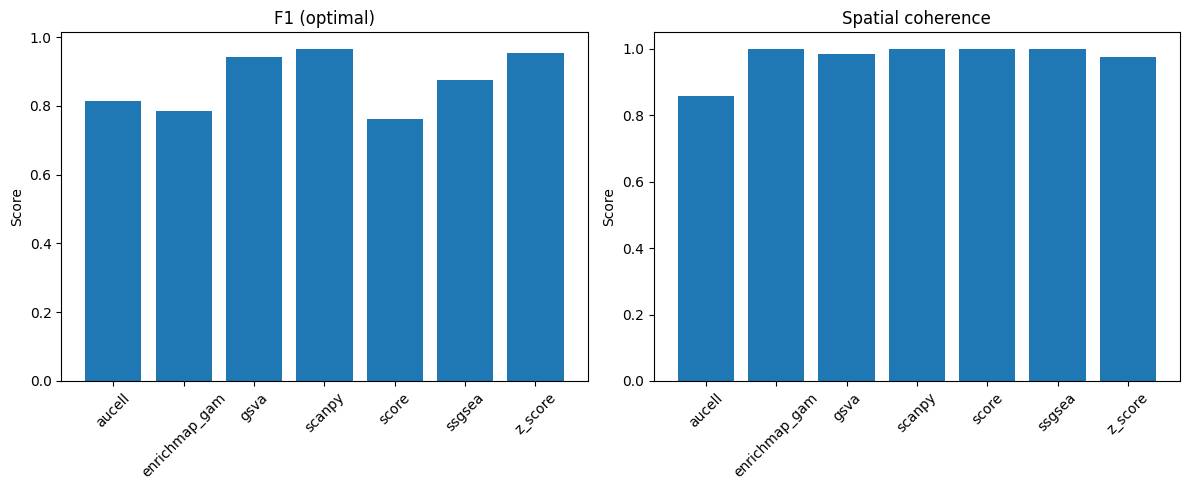

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "method": [
        "aucell",
        "enrichmap_gam",
        "gsva",
        "scanpy",
        "score",
        "ssgsea",
        "z_score",
    ],
    "F1_optimal": [0.814, 0.784, 0.943, 0.966, 0.763, 0.875, 0.953],
    "spatial_coherence": [0.858, 1.000, 0.985, 1.000, 1.000, 1.000, 0.976],
}

df = pd.DataFrame(data)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: F1
axes[0].bar(df["method"], df["F1_optimal"])
axes[0].set_title("F1 (optimal)")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=45)

# Panel 2: Spatial coherence
axes[1].bar(df["method"], df["spatial_coherence"])
axes[1].set_title("Spatial coherence")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

# Save as PDF
plt.savefig("figures/simulation_pyramidal_layer_f1_spatial_coherence_barplot.pdf", bbox_inches="tight")
plt.show()